In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. GENERATE / LOAD SENSOR DATA
# ---------------------------------------------------------
np.random.seed(42)

# Abuuridda xog gantaal ah oo u taagan sensor-ada mishiinka (Temperature & Vibration)
n_samples = 1000
time_stamps = pd.date_range(start="2026-01-01", periods=n_samples, freq="H")

# Caadiga (Normal operational data)
temp_normal = np.random.normal(loc=65, scale=5, size=n_samples)
vibr_normal = np.random.normal(loc=2.5, scale=0.5, size=n_samples)

df = pd.DataFrame({'timestamp': time_stamps, 'temperature': temp_normal, 'vibration': vibr_normal})

# Ku daridda cillado aan caadi ahayn (Inject Synthetic Anomalies)
df.loc[150:155, 'temperature'] += 30  # kulayl daran oo bixi kara
df.loc[500:505, 'vibration'] += 4.0   # ruxruxo badan

print("Xogta Sensor-ada waa la diyaariyay. Sifaha kowaad:")
print(df.head())

Xogta Sensor-ada waa la diyaariyay. Sifaha kowaad:
            timestamp  temperature  vibration
0 2026-01-01 00:00:00    67.483571   3.199678
1 2026-01-01 01:00:00    64.308678   2.962317
2 2026-01-01 02:00:00    68.238443   2.529815
3 2026-01-01 03:00:00    72.615149   2.176532
4 2026-01-01 04:00:00    63.829233   2.849112


C:\Users\muhid\AppData\Local\Temp\ipykernel_17008\944044063.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_stamps = pd.date_range(start="2026-01-01", periods=n_samples, freq="H")


In [4]:
# 2. PREPROCESSING & FEATURE SCALING
features = ['temperature', 'vibration']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

In [5]:
# 3. UNSUPERVISED MODEL: ISOLATION FOREST
# contamination: Saadaalinta boqolkiiba inta cilladood oo la filayo (e.g., 2%)
model = IsolationForest(contamination=0.02, random_state=42)
df['anomaly_score'] = model.fit_predict(scaled_features)

# Isolation forest: 1 = Normal, -1 = Anomaly
df['is_anomaly'] = df['anomaly_score'].map({1: 0, -1: 1})

num_anomalies = df['is_anomaly'].sum()
print(f"\n--- Wadar ahaan waxaa la ogaaday {num_anomalies} cilladood (Anomalies) ---")


--- Wadar ahaan waxaa la ogaaday 20 cilladood (Anomalies) ---


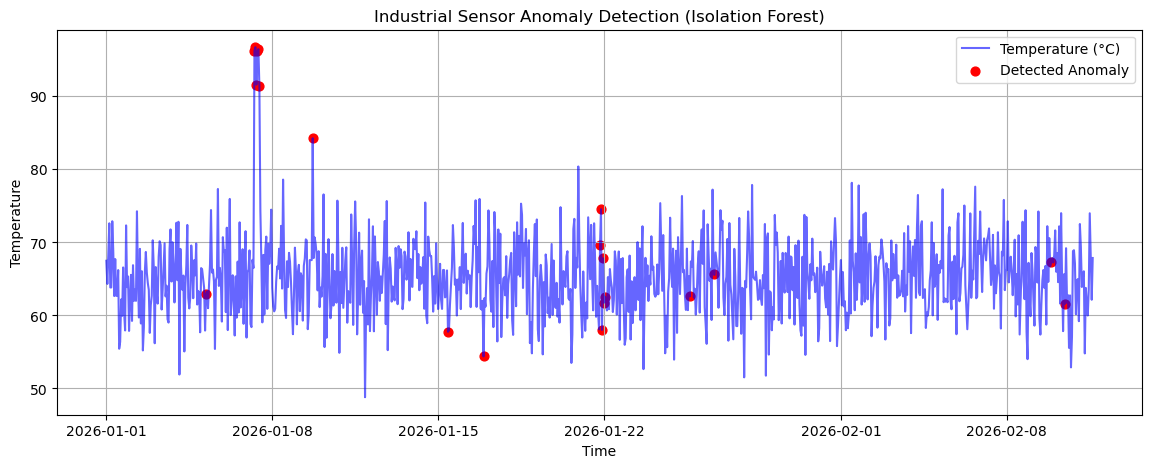

In [7]:
# 4. VISUALIZATION
plt.figure(figsize=(14, 5))

# Plot Temperature Over Time
plt.plot(df['timestamp'], df['temperature'], label='Temperature (°C)', color='blue', alpha=0.6)

# Highlight Anomalies
anomalies = df[df['is_anomaly'] == 1]
plt.scatter(anomalies['timestamp'], anomalies['temperature'], color='red', label='Detected Anomaly', s=40)

plt.title('Industrial Sensor Anomaly Detection (Isolation Forest)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)

plt.savefig('sensor_anomalies.png')
plt.show()